In [14]:
# =========================
# Shared Setup
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Load data
customers = pd.read_csv(r"cleaned_data\customers_clean.csv")
orders = pd.read_csv(r"cleaned_data\orders_clean.csv")
payments = pd.read_csv(r"cleaned_data\payments_clean.csv")
order_items = pd.read_csv(r"cleaned_data\order_items_clean.csv")
products = pd.read_csv(r"cleaned_data\products_clean.csv")
sellers = pd.read_csv(r"cleaned_data\sellers_clean.csv")

# Date parsing
customers["customer_since"] = pd.to_datetime(customers["customer_since"], format="mixed", errors="coerce")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], format="mixed", errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], format="mixed", errors="coerce")
orders["order_delivered_timestamp"] = pd.to_datetime(orders["order_delivered_timestamp"], format="mixed", errors="coerce")
orders["order_estimated_delivery"] = pd.to_datetime(orders["order_estimated_delivery"], format="mixed", errors="coerce")

# Helpers
comma_fmt = mticker.StrMethodFormatter("{x:,.0f}")

def rupee(x):
    return f"₹{x:,.2f}"

def crore(x):
    return f"₹{x/1e7:,.2f} Cr"

def add_bar_labels(ax, bars, fmt="{:,.0f}", is_horizontal=False, offset=3, fontsize=9):
    for bar in bars:
        if is_horizontal:
            val = bar.get_width()
            ax.text(val, bar.get_y() + bar.get_height()/2, f" {fmt.format(val)}",
                    va="center", ha="left", fontsize=fontsize, fontweight="bold")
        else:
            val = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, val, fmt.format(val),
                    ha="center", va="bottom", fontsize=fontsize, fontweight="bold")

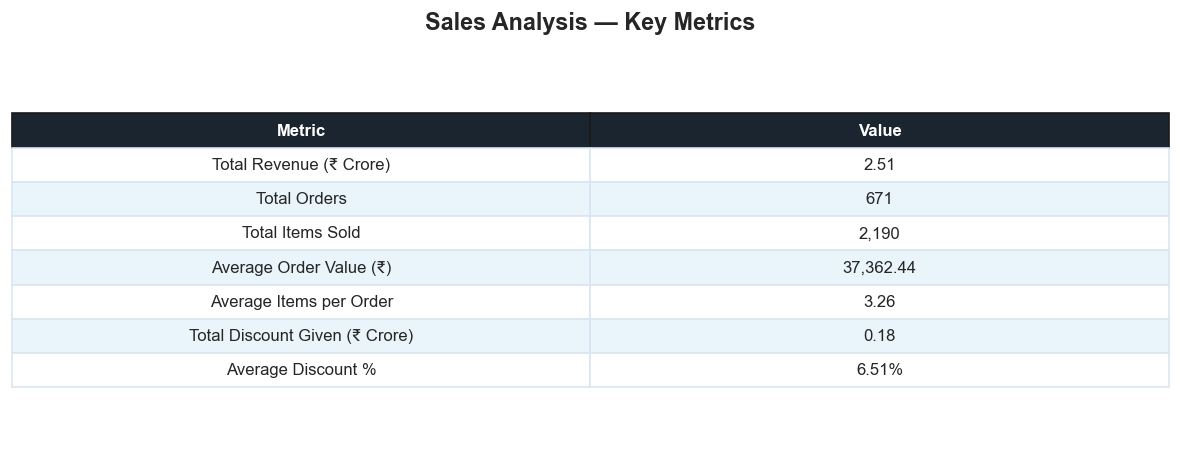

Raw Values:
Total Revenue: ₹25,070,198.04 (2.51 Cr)
Total Orders: 671
Total Items Sold: 2,190
Average Order Value: ₹37,362.44
Average Items per Order: 3.26
Total Discount Given: ₹1,827,492.57 (0.18 Cr)
Average Discount %: 6.51%


In [15]:
# =========================
# Section 1: Sales KPI Summary
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered")].copy()

# Order-level revenue to avoid duplication from multiple payment rows
order_revenue = (
    delivered_orders[["order_id"]]
    .merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
)

# Item-level cost/discount metrics
delivered_items = (
    order_items.merge(delivered_orders[["order_id"]], on="order_id", how="inner")
    .copy()
)
delivered_items["discount_amount"] = (delivered_items["unit_price"] - delivered_items["selling_price"]) * delivered_items["quantity"]

total_revenue = order_revenue["order_revenue"].sum()
total_orders = order_revenue["order_id"].nunique()
total_items_sold = delivered_items["quantity"].sum()
avg_order_value = order_revenue["order_revenue"].mean()
avg_items_per_order = total_items_sold / total_orders if total_orders else 0
total_discount = delivered_items["discount_amount"].sum()
avg_discount_pct = delivered_items["discount_pct"].mean()

kpi_df = pd.DataFrame({
    "Metric": [
        "Total Revenue (₹ Crore)",
        "Total Orders",
        "Total Items Sold",
        "Average Order Value (₹)",
        "Average Items per Order",
        "Total Discount Given (₹ Crore)",
        "Average Discount %"
    ],
    "Value": [
        f"{total_revenue/1e7:,.2f}",
        f"{total_orders:,}",
        f"{total_items_sold:,.0f}",
        f"{avg_order_value:,.2f}",
        f"{avg_items_per_order:,.2f}",
        f"{total_discount/1e7:,.2f}",
        f"{avg_discount_pct:,.2f}%"
    ]
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
ax.set_title("Sales Analysis — Key Metrics", fontsize=14, fontweight="bold", pad=14)

tbl = ax.table(
    cellText=kpi_df.values,
    colLabels=kpi_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1a252f")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#eaf4fb" if r % 2 == 0 else "white")
        cell.set_edgecolor("#d9e6f2")

plt.tight_layout()
plt.show()

print("Raw Values:")
print(f"Total Revenue: ₹{total_revenue:,.2f} ({total_revenue/1e7:,.2f} Cr)")
print(f"Total Orders: {total_orders:,}")
print(f"Total Items Sold: {total_items_sold:,.0f}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Average Items per Order: {avg_items_per_order:,.2f}")
print(f"Total Discount Given: ₹{total_discount:,.2f} ({total_discount/1e7:,.2f} Cr)")
print(f"Average Discount %: {avg_discount_pct:,.2f}%")

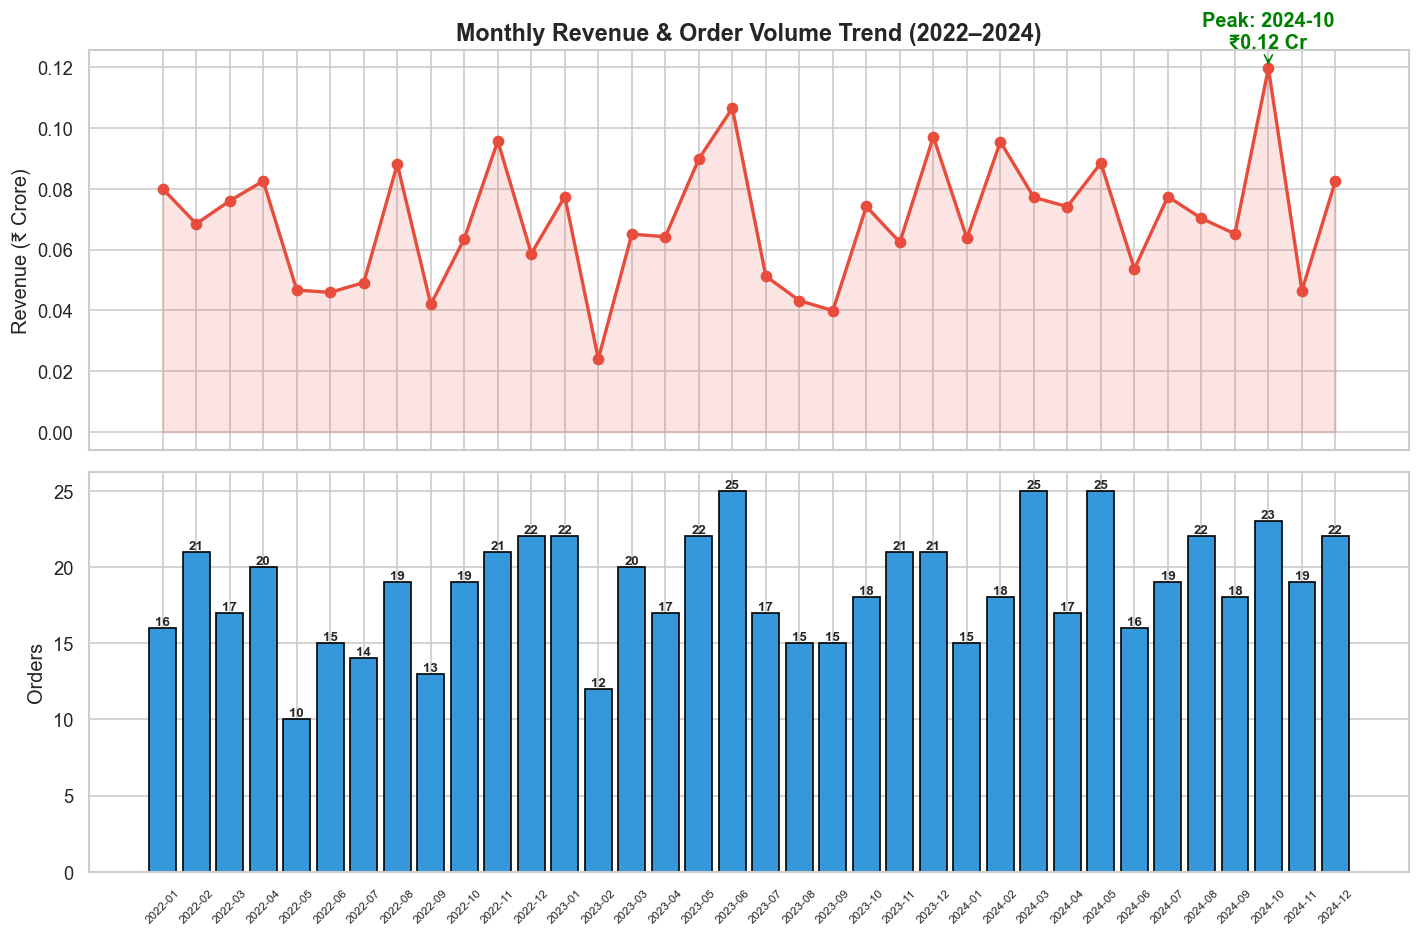

,Month,Monthly Revenue,Order Count,month_str
0,2022-01,800044.87,16,2022-01
1,2022-02,685040.31,21,2022-02
2,2022-03,760651.66,17,2022-03
3,2022-04,825593.43,20,2022-04
4,2022-05,466695.89,10,2022-05
5,2022-06,459255.66,15,2022-06
6,2022-07,491537.43,14,2022-07
7,2022-08,881414.47,19,2022-08
8,2022-09,419750.09,13,2022-09
9,2022-10,635889.01,19,2022-10


In [16]:
# =========================
# Section 2: Monthly Revenue Trend
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
delivered_orders["order_purchase_timestamp"] = pd.to_datetime(
    delivered_orders["order_purchase_timestamp"], format="mixed", errors="coerce"
)

order_revenue = (
    delivered_orders[["order_id", "order_purchase_timestamp"]]
    .merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
    .groupby(["order_id", "order_purchase_timestamp"], as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
)

order_revenue["month"] = order_revenue["order_purchase_timestamp"].dt.to_period("M")

monthly = (
    order_revenue.groupby("month")
    .agg(monthly_revenue=("order_revenue", "sum"), order_count=("order_id", "nunique"))
    .reset_index()
    .sort_values("month")
)

monthly["month_str"] = monthly["month"].astype(str)
peak_idx = monthly["monthly_revenue"].idxmax()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(monthly["month_str"], monthly["monthly_revenue"]/1e7, color="#e74c3c", marker="o", linewidth=2)
axes[0].fill_between(monthly["month_str"], monthly["monthly_revenue"]/1e7, alpha=0.15, color="#e74c3c")
axes[0].set_ylabel("Revenue (₹ Crore)")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
axes[0].set_title("Monthly Revenue & Order Volume Trend (2022–2024)", fontsize=14, fontweight="bold")

axes[0].annotate(
    f"Peak: {monthly.loc[peak_idx, 'month_str']}\n₹{monthly.loc[peak_idx, 'monthly_revenue']/1e7:,.2f} Cr",
    xy=(monthly.loc[peak_idx, "month_str"], monthly.loc[peak_idx, "monthly_revenue"]/1e7),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    color="green",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="green")
)

bars = axes[1].bar(monthly["month_str"], monthly["order_count"], color="#3498db", edgecolor="black")
axes[1].set_ylabel("Orders")
axes[1].yaxis.set_major_formatter(comma_fmt)
axes[1].tick_params(axis="x", rotation=45, labelsize=7)

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

display(monthly.rename(columns={"month": "Month", "monthly_revenue": "Monthly Revenue", "order_count": "Order Count"}))

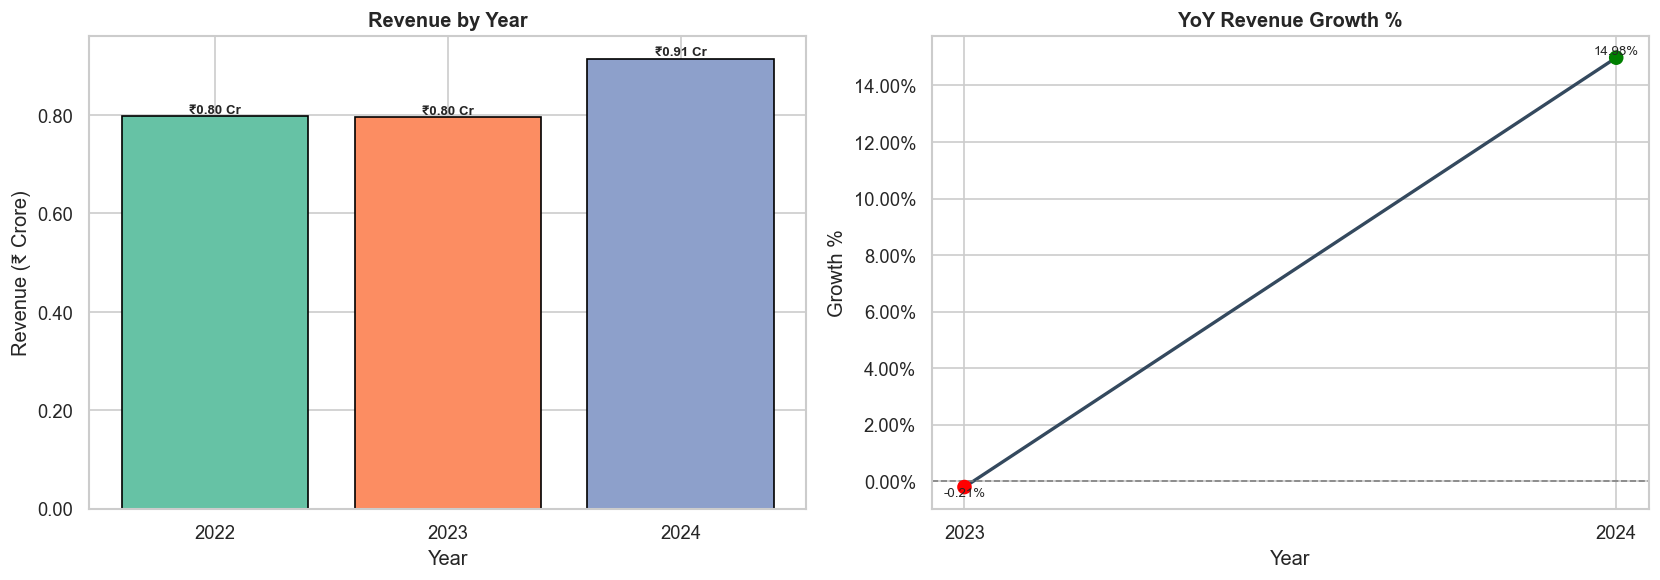

,Year,Total Revenue,Total Orders,YoY Revenue Growth %,YoY Order Growth %
0,2022,"₹7,970,438.61 (0.80 Cr)",207,-,-
1,2023,"₹7,954,010.69 (0.80 Cr)",225,-0.21%,8.70%
2,2024,"₹9,145,748.74 (0.91 Cr)",239,14.98%,6.22%


In [17]:
# =========================
# Section 3: Yearly Revenue & YoY Growth
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
delivered_orders["order_purchase_timestamp"] = pd.to_datetime(
    delivered_orders["order_purchase_timestamp"], format="mixed", errors="coerce"
)
delivered_orders["year"] = delivered_orders["order_purchase_timestamp"].dt.year

order_revenue = (
    delivered_orders[["order_id", "year"]]
    .merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
    .groupby(["order_id", "year"], as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
)

yearly = (
    order_revenue.groupby("year")
    .agg(total_revenue=("order_revenue", "sum"), total_orders=("order_id", "nunique"))
    .reset_index()
    .sort_values("year")
)

yearly["YoY Revenue Growth %"] = yearly["total_revenue"].pct_change() * 100
yearly["YoY Order Growth %"] = yearly["total_orders"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette("Set2", n_colors=len(yearly))
bars = axes[0].bar(yearly["year"].astype(str), yearly["total_revenue"]/1e7, color=colors, edgecolor="black")
axes[0].set_title("Revenue by Year", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Revenue (₹ Crore)")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar, val in zip(bars, yearly["total_revenue"]/1e7):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f"₹{val:,.2f} Cr",
                 ha="center", va="bottom", fontsize=8, fontweight="bold")

growth = yearly["YoY Revenue Growth %"]
line_colors = ["green" if v >= 0 else "red" for v in growth.fillna(0)]

axes[1].plot(yearly["year"].astype(str), growth, color="#34495e", linewidth=2, marker="o")
axes[1].scatter(yearly["year"].astype(str), growth, c=line_colors, s=60, zorder=3)
axes[1].axhline(0, linestyle="--", color="gray", linewidth=1)
axes[1].set_title("YoY Revenue Growth %", fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Growth %")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}%"))

for x, y in zip(yearly["year"].astype(str), growth):
    if pd.notna(y):
        axes[1].text(x, y, f"{y:,.2f}%", ha="center", va="bottom" if y >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.show()

summary = yearly.copy()
summary["total_revenue"] = summary["total_revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
summary["YoY Revenue Growth %"] = summary["YoY Revenue Growth %"].map(lambda x: "-" if pd.isna(x) else f"{x:,.2f}%")
summary["YoY Order Growth %"] = summary["YoY Order Growth %"].map(lambda x: "-" if pd.isna(x) else f"{x:,.2f}%")
display(summary.rename(columns={
    "year": "Year",
    "total_revenue": "Total Revenue",
    "total_orders": "Total Orders",
    "YoY Revenue Growth %": "YoY Revenue Growth %",
    "YoY Order Growth %": "YoY Order Growth %"
}))

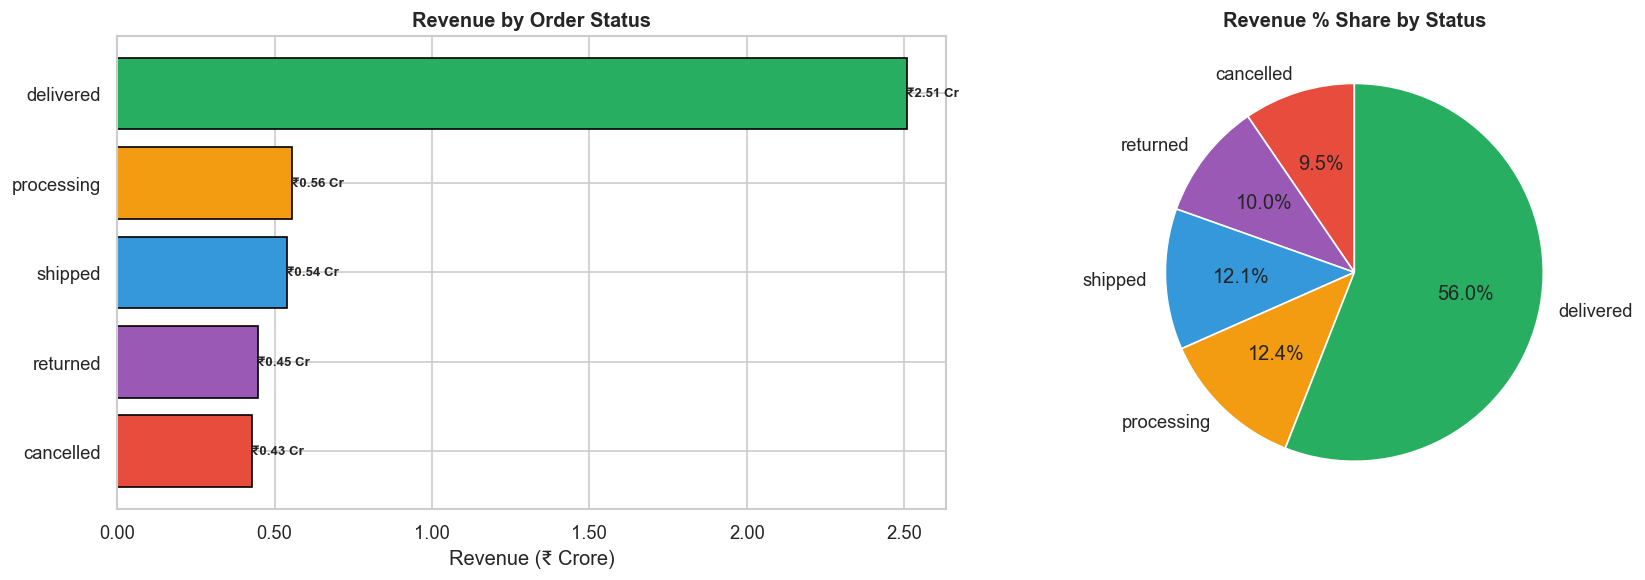

,Order Status,Order Count,Total Revenue,% Share of Revenue,color
0,cancelled,105,"₹4,275,004.79 (0.43 Cr)",9.54%,#e74c3c
3,returned,136,"₹4,488,759.62 (0.45 Cr)",10.02%,#9b59b6
4,shipped,135,"₹5,405,464.16 (0.54 Cr)",12.06%,#3498db
2,processing,119,"₹5,564,892.30 (0.56 Cr)",12.42%,#f39c12
1,delivered,671,"₹25,070,198.04 (2.51 Cr)",55.95%,#27ae60


In [18]:
# =========================
# Section 4: Revenue by Order Status
# =========================

order_revenue_all = (
    orders[["order_id", "order_status"]]
    .merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
    .groupby(["order_id", "order_status"], as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
)

status_summary = (
    order_revenue_all.groupby("order_status")
    .agg(order_count=("order_id", "nunique"), total_revenue=("order_revenue", "sum"))
    .reset_index()
)

status_summary["revenue_share"] = (status_summary["total_revenue"] / status_summary["total_revenue"].sum()) * 100

status_colors = {
    "delivered": "#27ae60",
    "shipped": "#3498db",
    "processing": "#f39c12",
    "cancelled": "#e74c3c",
    "returned": "#9b59b6"
}
status_summary["color"] = status_summary["order_status"].map(status_colors).fillna("#95a5a6")
status_summary = status_summary.sort_values("total_revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].barh(status_summary["order_status"], status_summary["total_revenue"]/1e7,
                    color=status_summary["color"], edgecolor="black")
axes[0].set_title("Revenue by Order Status", fontweight="bold")
axes[0].set_xlabel("Revenue (₹ Crore)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars:
    val = bar.get_width()
    axes[0].text(val, bar.get_y() + bar.get_height()/2, f"₹{val:,.2f} Cr",
                 va="center", ha="left", fontsize=8, fontweight="bold")

axes[1].pie(
    status_summary["total_revenue"],
    labels=status_summary["order_status"],
    autopct="%1.1f%%",
    startangle=90,
    colors=status_summary["color"],
    wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Revenue % Share by Status", fontweight="bold")

plt.tight_layout()
plt.show()

table = status_summary.copy()
table["total_revenue"] = table["total_revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
table["revenue_share"] = table["revenue_share"].map(lambda x: f"{x:,.2f}%")
display(table.rename(columns={
    "order_status": "Order Status",
    "order_count": "Order Count",
    "total_revenue": "Total Revenue",
    "revenue_share": "% Share of Revenue"
}))

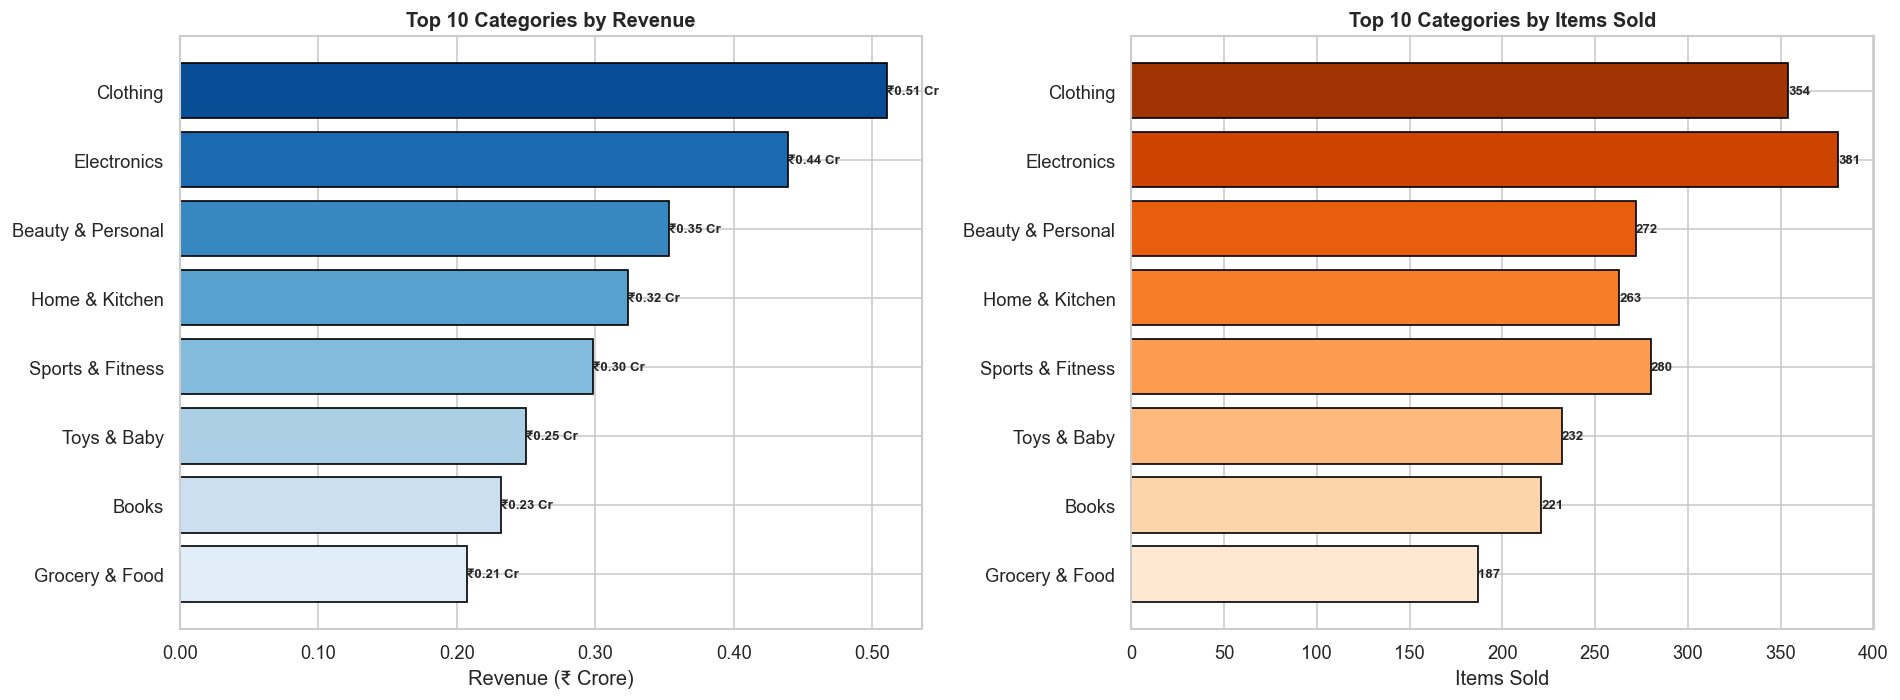

,Category,Revenue,Items Sold,Orders,Avg Price
2,Clothing,5103515.11,354,130,13803.876324
3,Electronics,4390681.14,381,142,11722.707200
0,Beauty & Personal,3528622.80,272,101,13145.683619
5,Home & Kitchen,3233724.70,263,110,12104.463063
6,Sports & Fitness,2982523.58,280,107,10797.472844
7,Toys & Baby,2496415.36,232,85,11229.946744
1,Books,2317776.78,221,90,10493.138041
4,Grocery & Food,2073166.98,187,70,11344.793239


In [19]:
# =========================
# Section 5: Top 10 Product Categories by Revenue
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered"), ["order_id"]].copy()

item_full = (
    order_items.merge(delivered_orders, on="order_id", how="inner")
    .merge(products[["product_id", "product_category"]], on="product_id", how="left")
)

cat_summary = (
    item_full.groupby("product_category")
    .agg(
        total_revenue=("total_value", "sum"),
        total_items_sold=("quantity", "sum"),
        number_of_orders=("order_id", "nunique"),
        avg_selling_price=("selling_price", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(
    cat_summary["product_category"],
    cat_summary["total_revenue"]/1e7,
    color=sns.color_palette("Blues_r", n_colors=len(cat_summary)),
    edgecolor="black"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Categories by Revenue", fontweight="bold")
axes[0].set_xlabel("Revenue (₹ Crore)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars1:
    val = bar.get_width()
    axes[0].text(val, bar.get_y() + bar.get_height()/2, f"₹{val:,.2f} Cr",
                 va="center", ha="left", fontsize=8, fontweight="bold")

bars2 = axes[1].barh(
    cat_summary["product_category"],
    cat_summary["total_items_sold"],
    color=sns.color_palette("Oranges_r", n_colors=len(cat_summary)),
    edgecolor="black"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Categories by Items Sold", fontweight="bold")
axes[1].set_xlabel("Items Sold")
axes[1].xaxis.set_major_formatter(comma_fmt)

for bar in bars2:
    val = bar.get_width()
    axes[1].text(val, bar.get_y() + bar.get_height()/2, f"{val:,.0f}",
                 va="center", ha="left", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

display(cat_summary.rename(columns={
    "product_category": "Category",
    "total_revenue": "Revenue",
    "total_items_sold": "Items Sold",
    "number_of_orders": "Orders",
    "avg_selling_price": "Avg Price"
}))

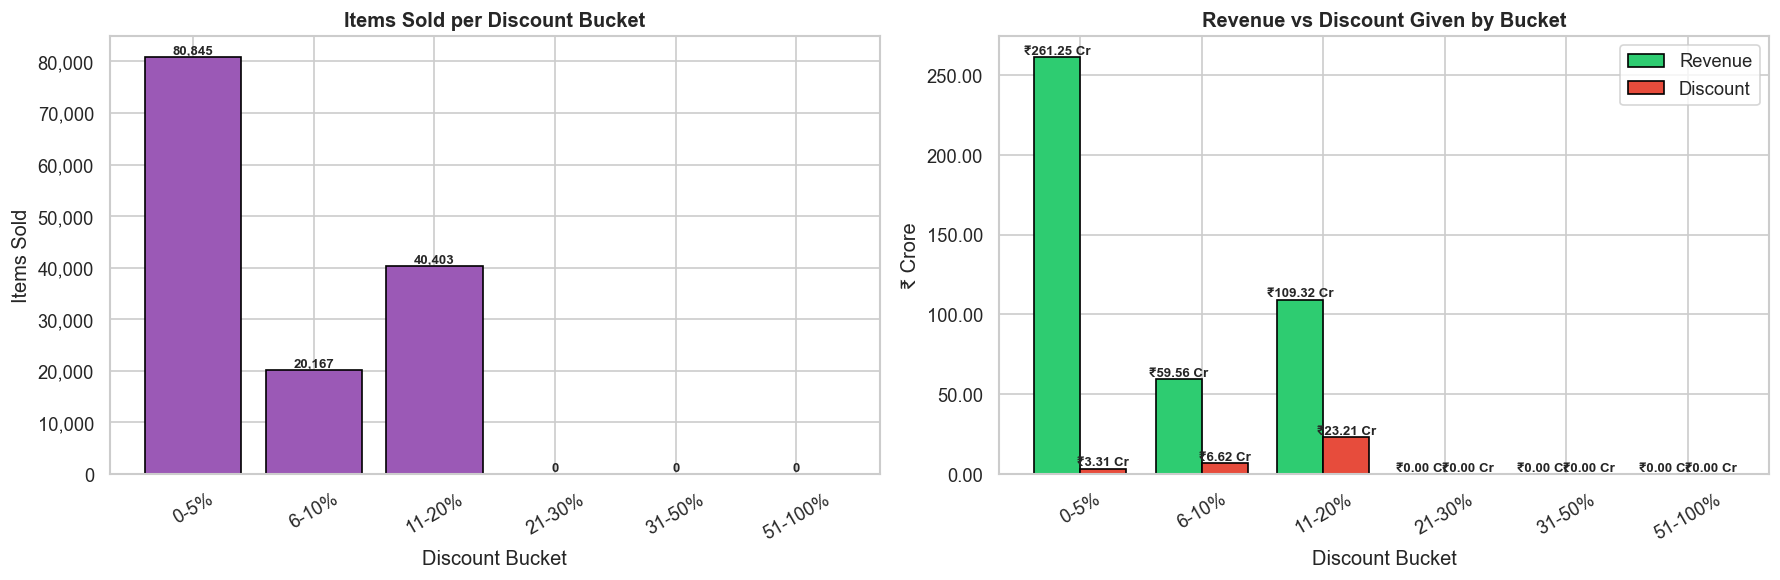

,Discount Bucket,Number of Items,Total Revenue,Total Discount Given,Avg Selling Price
0,0-5%,80845,"₹2,612,544,226.22 (261.25 Cr)","₹33,080,291.66 (3.31 Cr)","₹12,894.82"
1,6-10%,20167,"₹595,649,478.99 (59.56 Cr)","₹66,183,267.74 (6.62 Cr)","₹11,761.40"
2,11-20%,40403,"₹1,093,154,968.67 (109.32 Cr)","₹232,141,012.59 (23.21 Cr)","₹10,791.16"
3,21-30%,0,₹0.00 (0.00 Cr),₹0.00 (0.00 Cr),₹nan
4,31-50%,0,₹0.00 (0.00 Cr),₹0.00 (0.00 Cr),₹nan
5,51-100%,0,₹0.00 (0.00 Cr),₹0.00 (0.00 Cr),₹nan


In [20]:
# =========================
# Section 6: Discount Impact on Revenue
# =========================

discount_df = order_items.copy()
discount_df["discount_amount"] = (discount_df["unit_price"] - discount_df["selling_price"]) * discount_df["quantity"]

bins = [0, 5, 10, 20, 30, 50, 100]
labels = ["0-5%", "6-10%", "11-20%", "21-30%", "31-50%", "51-100%"]

discount_df["discount_bucket"] = pd.cut(
    discount_df["discount_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

disc_summary = (
    discount_df.groupby("discount_bucket", observed=False)
    .agg(
        number_of_items=("order_item_id", "count"),
        total_revenue=("total_value", "sum"),
        total_discount_given=("discount_amount", "sum"),
        avg_selling_price=("selling_price", "mean")
    )
    .reindex(labels)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(disc_summary["discount_bucket"].astype(str), disc_summary["number_of_items"],
                   color="#9b59b6", edgecolor="black")
axes[0].set_title("Items Sold per Discount Bucket", fontweight="bold")
axes[0].set_xlabel("Discount Bucket")
axes[0].set_ylabel("Items Sold")
axes[0].yaxis.set_major_formatter(comma_fmt)
axes[0].tick_params(axis="x", rotation=30)

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

x = np.arange(len(disc_summary))
w = 0.38
rev_bars = axes[1].bar(x - w/2, disc_summary["total_revenue"]/1e7, width=w, color="#2ecc71", edgecolor="black", label="Revenue")
dis_bars = axes[1].bar(x + w/2, disc_summary["total_discount_given"]/1e7, width=w, color="#e74c3c", edgecolor="black", label="Discount")

axes[1].set_xticks(x)
axes[1].set_xticklabels(disc_summary["discount_bucket"].astype(str), rotation=30)
axes[1].set_title("Revenue vs Discount Given by Bucket", fontweight="bold")
axes[1].set_xlabel("Discount Bucket")
axes[1].set_ylabel("₹ Crore")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
axes[1].legend()

for bars_set in [rev_bars, dis_bars]:
    for bar in bars_set:
        val = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, val, f"₹{val:,.2f} Cr",
                     ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

disc_display = disc_summary.copy()
disc_display["total_revenue"] = disc_display["total_revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
disc_display["total_discount_given"] = disc_display["total_discount_given"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
disc_display["avg_selling_price"] = disc_display["avg_selling_price"].map(lambda x: f"₹{x:,.2f}")
display(disc_display.rename(columns={
    "discount_bucket": "Discount Bucket",
    "number_of_items": "Number of Items",
    "total_revenue": "Total Revenue",
    "total_discount_given": "Total Discount Given",
    "avg_selling_price": "Avg Selling Price"
}))

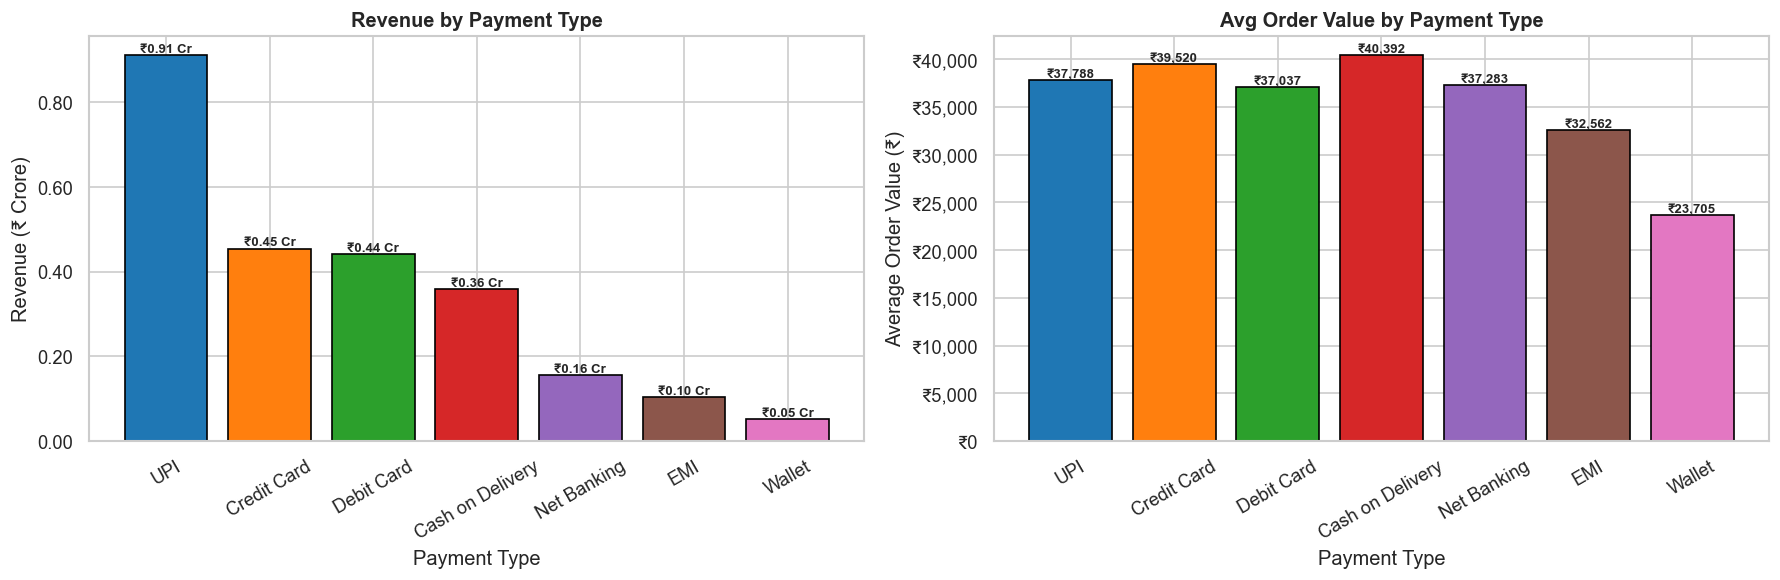

,Payment Type,Total Revenue,Number of Orders,Avg Order Value,Avg Installments
5,UPI,"₹9,106,870.84 (0.91 Cr)",240,"₹37,787.85",1.00
1,Credit Card,"₹4,544,755.53 (0.45 Cr)",115,"₹39,519.61",1.00
2,Debit Card,"₹4,407,413.71 (0.44 Cr)",119,"₹37,037.09",1.00
0,Cash on Delivery,"₹3,594,846.86 (0.36 Cr)",89,"₹40,391.54",1.00
4,Net Banking,"₹1,565,894.39 (0.16 Cr)",41,"₹37,283.20",1.00
3,EMI,"₹1,041,980.93 (0.10 Cr)",32,"₹32,561.90",7.59
6,Wallet,"₹521,500.52 (0.05 Cr)",22,"₹23,704.57",1.00


In [21]:
# =========================
# Section 7: Revenue Breakdown by Payment Type
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered"), ["order_id"]].copy()

pay_full = (
    delivered_orders.merge(payments, on="order_id", how="left")
    .copy()
)

pay_full = pay_full.loc[pay_full["payment_type"].ne("Unknown")]

payment_summary = (
    pay_full.groupby("payment_type")
    .agg(
        total_revenue=("payment_value", "sum"),
        number_of_orders=("order_id", "nunique"),
        avg_order_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = sns.color_palette("tab10", n_colors=len(payment_summary))

bars1 = axes[0].bar(payment_summary["payment_type"], payment_summary["total_revenue"]/1e7,
                    color=colors, edgecolor="black")
axes[0].set_title("Revenue by Payment Type", fontweight="bold")
axes[0].set_xlabel("Payment Type")
axes[0].set_ylabel("Revenue (₹ Crore)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars1:
    val = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f"₹{val:,.2f} Cr",
                 ha="center", va="bottom", fontsize=8, fontweight="bold")

bars2 = axes[1].bar(payment_summary["payment_type"], payment_summary["avg_order_value"],
                    color=colors, edgecolor="black")
axes[1].set_title("Avg Order Value by Payment Type", fontweight="bold")
axes[1].set_xlabel("Payment Type")
axes[1].set_ylabel("Average Order Value (₹)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("₹{x:,.0f}"))

for bar in bars2:
    val = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f"₹{val:,.0f}",
                 ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

payment_display = payment_summary.copy()
payment_display["total_revenue"] = payment_display["total_revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
payment_display["avg_order_value"] = payment_display["avg_order_value"].map(lambda x: f"₹{x:,.2f}")
payment_display["avg_installments"] = payment_display["avg_installments"].map(lambda x: f"{x:,.2f}")
display(payment_display.rename(columns={
    "payment_type": "Payment Type",
    "total_revenue": "Total Revenue",
    "number_of_orders": "Number of Orders",
    "avg_order_value": "Avg Order Value",
    "avg_installments": "Avg Installments"
}))

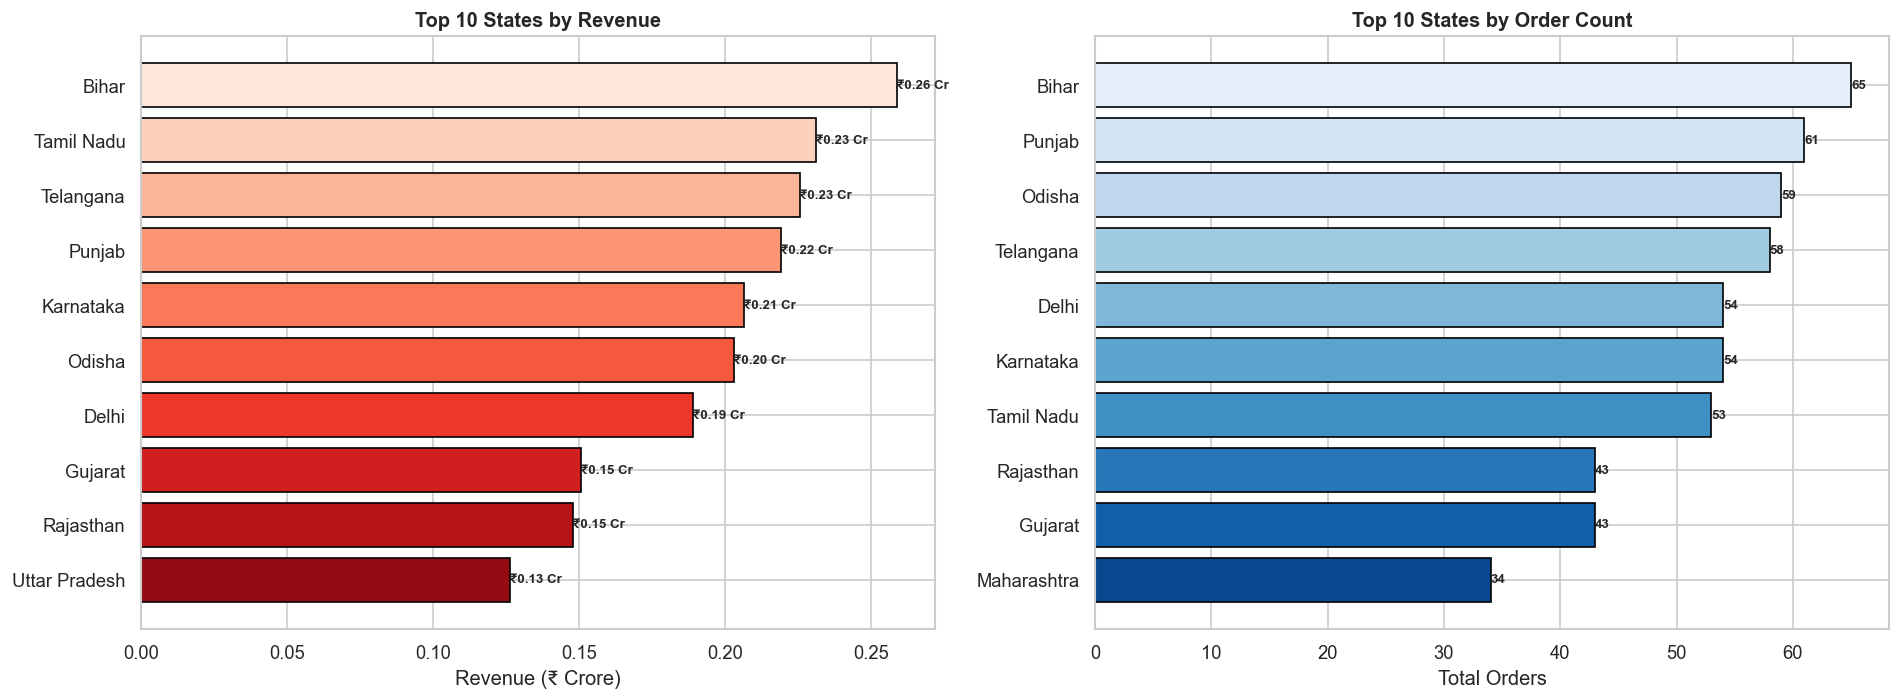

,State,Total Revenue,Total Orders,Avg Order Value,Unique Customers
0,Bihar,"₹2,588,823.48 (0.26 Cr)",65,"₹39,828.05",20
11,Tamil Nadu,"₹2,309,203.51 (0.23 Cr)",53,"₹43,569.88",21
12,Telangana,"₹2,255,129.10 (0.23 Cr)",58,"₹38,881.54",16
9,Punjab,"₹2,190,047.96 (0.22 Cr)",61,"₹35,902.43",19
4,Karnataka,"₹2,063,387.58 (0.21 Cr)",54,"₹38,210.88",27
8,Odisha,"₹2,029,068.45 (0.20 Cr)",59,"₹34,390.99",16
1,Delhi,"₹1,890,334.19 (0.19 Cr)",54,"₹35,006.19",20
2,Gujarat,"₹1,506,986.65 (0.15 Cr)",43,"₹35,046.20",21
10,Rajasthan,"₹1,478,973.54 (0.15 Cr)",43,"₹34,394.73",22
13,Uttar Pradesh,"₹1,262,494.31 (0.13 Cr)",31,"₹40,725.62",15


In [22]:
# =========================
# Section 8: Sales by State
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered"), ["order_id", "customer_id"]].copy()

order_level = (
    delivered_orders
    .merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
    .groupby(["order_id", "customer_id"], as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
)

state_summary = (
    order_level.groupby("customer_state")
    .agg(
        total_revenue=("order_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        avg_order_value=("order_revenue", "mean"),
        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top_rev = state_summary.head(10).sort_values("total_revenue", ascending=True)
top_orders = state_summary.sort_values("total_orders", ascending=False).head(10).sort_values("total_orders", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(top_rev["customer_state"], top_rev["total_revenue"]/1e7,
                     color=sns.color_palette("Reds_r", n_colors=len(top_rev)), edgecolor="black")
axes[0].set_title("Top 10 States by Revenue", fontweight="bold")
axes[0].set_xlabel("Revenue (₹ Crore)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
for bar in bars1:
    val = bar.get_width()
    axes[0].text(val, bar.get_y() + bar.get_height()/2, f"₹{val:,.2f} Cr",
                 va="center", ha="left", fontsize=8, fontweight="bold")

bars2 = axes[1].barh(top_orders["customer_state"], top_orders["total_orders"],
                     color=sns.color_palette("Blues_r", n_colors=len(top_orders)), edgecolor="black")
axes[1].set_title("Top 10 States by Order Count", fontweight="bold")
axes[1].set_xlabel("Total Orders")
axes[1].xaxis.set_major_formatter(comma_fmt)
for bar in bars2:
    val = bar.get_width()
    axes[1].text(val, bar.get_y() + bar.get_height()/2, f"{val:,.0f}",
                 va="center", ha="left", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

state_display = state_summary.copy()
state_display["total_revenue"] = state_display["total_revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
state_display["avg_order_value"] = state_display["avg_order_value"].map(lambda x: f"₹{x:,.2f}")
display(state_display.rename(columns={
    "customer_state": "State",
    "total_revenue": "Total Revenue",
    "total_orders": "Total Orders",
    "avg_order_value": "Avg Order Value",
    "unique_customers": "Unique Customers"
}))

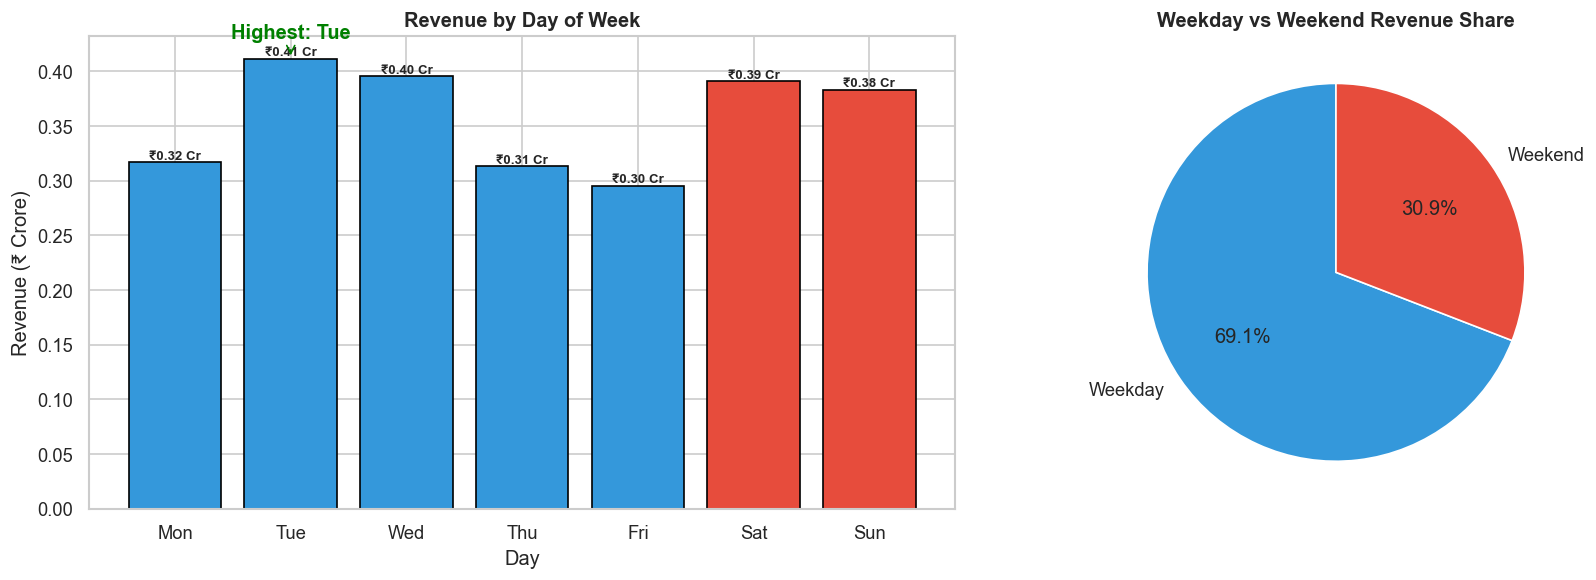

,Day,Total Revenue,Order Count,Avg Order Value
0,Mon,"₹3,167,950.26 (0.32 Cr)",86,"₹36,836.63"
1,Tue,"₹4,115,457.10 (0.41 Cr)",103,"₹39,571.70"
2,Wed,"₹3,957,741.77 (0.40 Cr)",90,"₹43,974.91"
3,Thu,"₹3,133,352.81 (0.31 Cr)",92,"₹34,058.18"
4,Fri,"₹2,954,090.24 (0.30 Cr)",94,"₹31,426.49"
5,Sat,"₹3,909,786.74 (0.39 Cr)",106,"₹36,884.78"
6,Sun,"₹3,831,819.12 (0.38 Cr)",100,"₹37,938.80"


In [23]:
# =========================
# Section 9: Weekday vs Weekend Sales Pattern
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered"), ["order_id", "order_purchase_timestamp"]].copy()
delivered_orders["order_purchase_timestamp"] = pd.to_datetime(
    delivered_orders["order_purchase_timestamp"], format="mixed", errors="coerce"
)

weekday_base = (
    delivered_orders.merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
    .groupby(["order_id", "order_purchase_timestamp"], as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
)

weekday_base["day_of_week"] = weekday_base["order_purchase_timestamp"].dt.dayofweek
weekday_base["day_name"] = weekday_base["day_of_week"].map({
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
})
weekday_base["is_weekend"] = weekday_base["day_of_week"].isin([5, 6])

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_summary = (
    weekday_base.groupby("day_name")
    .agg(
        total_revenue=("order_revenue", "sum"),
        order_count=("order_id", "nunique"),
        avg_order_value=("order_revenue", "mean")
    )
    .reindex(day_order)
    .reset_index()
)

weekend_share = (
    weekday_base.groupby("is_weekend")["order_revenue"]
    .sum()
    .reset_index()
)
weekend_share["label"] = weekend_share["is_weekend"].map({False: "Weekday", True: "Weekend"})

highest_day = day_summary.loc[day_summary["total_revenue"].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

day_colors = ["#3498db" if d not in ["Sat", "Sun"] else "#e74c3c" for d in day_summary["day_name"]]
bars = axes[0].bar(day_summary["day_name"], day_summary["total_revenue"]/1e7, color=day_colors, edgecolor="black")
axes[0].set_title("Revenue by Day of Week", fontweight="bold")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Revenue (₹ Crore)")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars:
    val = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f"₹{val:,.2f} Cr",
                 ha="center", va="bottom", fontsize=8, fontweight="bold")

axes[0].annotate(
    f"Highest: {highest_day['day_name']}",
    xy=(highest_day["day_name"], highest_day["total_revenue"]/1e7),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    color="green",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="green")
)

axes[1].pie(
    weekend_share["order_revenue"],
    labels=weekend_share["label"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#3498db", "#e74c3c"],
    wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Weekday vs Weekend Revenue Share", fontweight="bold")

plt.tight_layout()
plt.show()

day_display = day_summary.copy()
day_display["total_revenue"] = day_display["total_revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
day_display["avg_order_value"] = day_display["avg_order_value"].map(lambda x: f"₹{x:,.2f}")
display(day_display.rename(columns={
    "day_name": "Day",
    "total_revenue": "Total Revenue",
    "order_count": "Order Count",
    "avg_order_value": "Avg Order Value"
}))

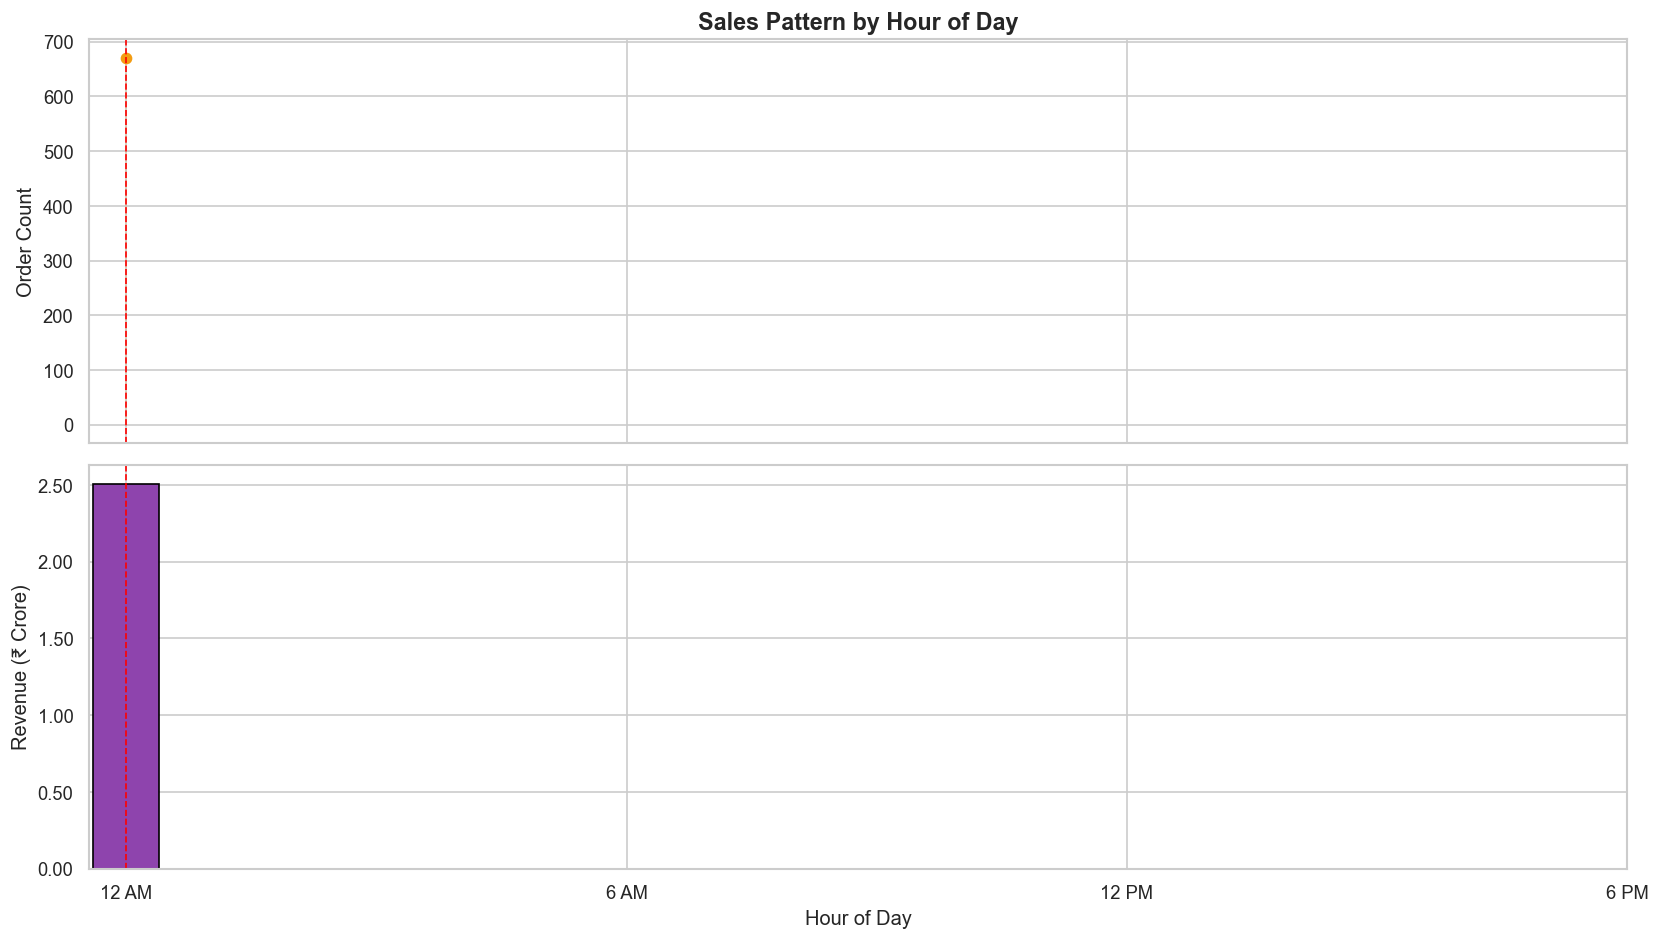

Peak Hour: 0:00
Peak Hour Order Count: 671
Peak Hour Revenue: ₹25,070,198.04 (2.51 Cr)


In [24]:
# =========================
# Section 10: Hourly Sales Pattern
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered"), ["order_id", "order_purchase_timestamp"]].copy()
delivered_orders["order_purchase_timestamp"] = pd.to_datetime(
    delivered_orders["order_purchase_timestamp"], format="mixed", errors="coerce"
)

hour_base = (
    delivered_orders.merge(payments[["order_id", "payment_value"]], on="order_id", how="left")
    .groupby(["order_id", "order_purchase_timestamp"], as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
)

hour_base["hour"] = hour_base["order_purchase_timestamp"].dt.hour

hour_summary = (
    hour_base.groupby("hour")
    .agg(order_count=("order_id", "nunique"), total_revenue=("order_revenue", "sum"))
    .reset_index()
    .sort_values("hour")
)

peak_hour = hour_summary.loc[hour_summary["order_count"].idxmax(), "hour"]
peak_details = hour_summary.loc[hour_summary["hour"].eq(peak_hour)].iloc[0]

hour_labels = {0: "12 AM", 6: "6 AM", 12: "12 PM", 18: "6 PM"}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(hour_summary["hour"], hour_summary["order_count"], color="#f39c12", marker="o", linewidth=2)
axes[0].fill_between(hour_summary["hour"], hour_summary["order_count"], alpha=0.15, color="#f39c12")
axes[0].axvline(peak_hour, linestyle="--", color="red", linewidth=1)
axes[0].set_title("Sales Pattern by Hour of Day", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Order Count")
axes[0].yaxis.set_major_formatter(comma_fmt)

axes[1].bar(hour_summary["hour"], hour_summary["total_revenue"]/1e7, color="#8e44ad", edgecolor="black")
axes[1].axvline(peak_hour, linestyle="--", color="red", linewidth=1)
axes[1].set_ylabel("Revenue (₹ Crore)")
axes[1].set_xlabel("Hour of Day")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for ax in axes:
    ax.set_xticks([0, 6, 12, 18])
    ax.set_xticklabels([hour_labels.get(x, str(x)) for x in [0, 6, 12, 18]])

plt.tight_layout()
plt.show()

print(f"Peak Hour: {peak_hour}:00")
print(f"Peak Hour Order Count: {int(peak_details['order_count']):,}")
print(f"Peak Hour Revenue: ₹{peak_details['total_revenue']:,.2f} ({peak_details['total_revenue']/1e7:,.2f} Cr)")

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


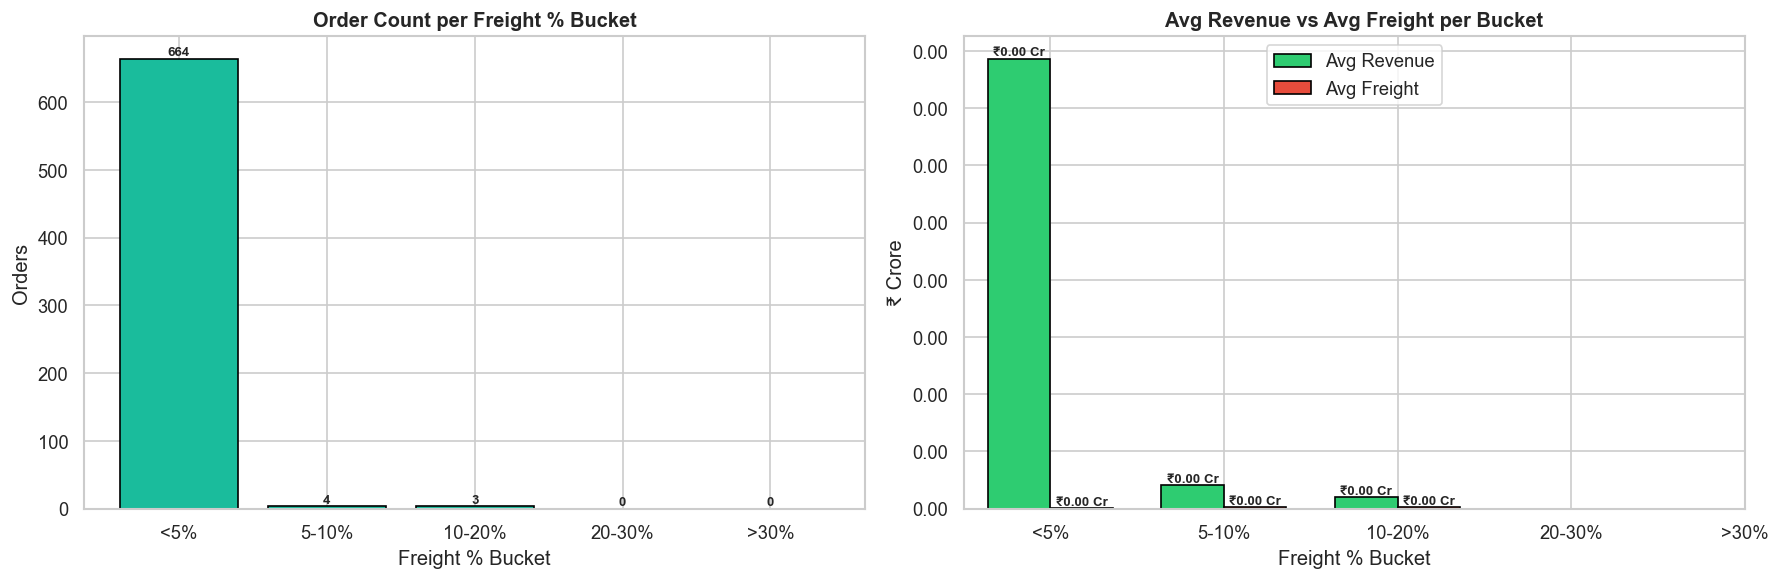

,Freight % Bucket,Number of Orders,Avg Revenue per Order,Avg Freight per Order
0,<5%,664,"₹39,330.29",₹58.65
1,5-10%,4,"₹2,049.06",₹139.33
2,10-20%,3,₹971.83,₹128.36
3,20-30%,0,₹nan,₹nan
4,>30%,0,₹nan,₹nan


In [25]:
# =========================
# Section 11: Freight Cost vs Revenue Analysis
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered"), ["order_id"]].copy()

freight_order = (
    order_items.merge(delivered_orders, on="order_id", how="inner")
    .groupby("order_id", as_index=False)
    .agg(
        total_revenue=("total_value", "sum"),
        total_freight=("freight_value", "sum")
    )
)

freight_order["freight_pct"] = (freight_order["total_freight"] / freight_order["total_revenue"]) * 100

bins = [0, 5, 10, 20, 30, 100]
labels = ["<5%", "5-10%", "10-20%", "20-30%", ">30%"]

freight_order["freight_bucket"] = pd.cut(
    freight_order["freight_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

freight_summary = (
    freight_order.groupby("freight_bucket", observed=False)
    .agg(
        number_of_orders=("order_id", "nunique"),
        avg_revenue_per_order=("total_revenue", "mean"),
        avg_freight_per_order=("total_freight", "mean")
    )
    .reindex(labels)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars1 = axes[0].bar(freight_summary["freight_bucket"].astype(str), freight_summary["number_of_orders"],
                    color="#1abc9c", edgecolor="black")
axes[0].set_title("Order Count per Freight % Bucket", fontweight="bold")
axes[0].set_xlabel("Freight % Bucket")
axes[0].set_ylabel("Orders")
axes[0].yaxis.set_major_formatter(comma_fmt)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

x = np.arange(len(freight_summary))
w = 0.36
b1 = axes[1].bar(x - w/2, freight_summary["avg_revenue_per_order"]/1e7, width=w, color="#2ecc71", edgecolor="black", label="Avg Revenue")
b2 = axes[1].bar(x + w/2, freight_summary["avg_freight_per_order"]/1e7, width=w, color="#e74c3c", edgecolor="black", label="Avg Freight")
axes[1].set_xticks(x)
axes[1].set_xticklabels(freight_summary["freight_bucket"].astype(str))
axes[1].set_title("Avg Revenue vs Avg Freight per Bucket", fontweight="bold")
axes[1].set_xlabel("Freight % Bucket")
axes[1].set_ylabel("₹ Crore")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
axes[1].legend()

for bars_set in [b1, b2]:
    for bar in bars_set:
        val = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, val, f"₹{val:,.2f} Cr",
                     ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

freight_display = freight_summary.copy()
freight_display["avg_revenue_per_order"] = freight_display["avg_revenue_per_order"].map(lambda x: f"₹{x:,.2f}")
freight_display["avg_freight_per_order"] = freight_display["avg_freight_per_order"].map(lambda x: f"₹{x:,.2f}")
display(freight_display.rename(columns={
    "freight_bucket": "Freight % Bucket",
    "number_of_orders": "Number of Orders",
    "avg_revenue_per_order": "Avg Revenue per Order",
    "avg_freight_per_order": "Avg Freight per Order"
}))

In [26]:
# =========================
# Section 12: Export Sales Summary for Power BI
# =========================

# Delivered orders only
delivered_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
delivered_orders["order_purchase_timestamp"] = pd.to_datetime(
    delivered_orders["order_purchase_timestamp"], format="mixed", errors="coerce"
)

# Order-level payment summary
order_pay = (
    delivered_orders[["order_id", "customer_id", "order_purchase_timestamp"]]
    .merge(payments, on="order_id", how="left")
    .groupby(["order_id", "customer_id", "order_purchase_timestamp"], as_index=False)
    .agg(
        total_revenue=("payment_value", "sum"),
        payment_type=("payment_type", "first"),
        avg_installments=("payment_installments", "mean")
    )
)

# Item-level order summary
order_items_summary = (
    order_items.merge(delivered_orders[["order_id"]], on="order_id", how="inner")
    .groupby("order_id", as_index=False)
    .agg(
        total_items_sold=("quantity", "sum"),
        total_discount=("discount_pct", lambda s: np.nan),  # placeholder replaced below
        total_freight=("freight_value", "sum")
    )
)

# Correct discount total separately
item_discount = (
    order_items.merge(delivered_orders[["order_id"]], on="order_id", how="inner")
    .assign(discount_amount=lambda df: (df["unit_price"] - df["selling_price"]) * df["quantity"])
    .groupby("order_id", as_index=False)
    .agg(total_discount=("discount_amount", "sum"))
)

order_items_summary = order_items_summary.drop(columns=["total_discount"]).merge(item_discount, on="order_id", how="left")

# Merge order-level, item-level, customer attributes
sales_master = (
    order_pay.merge(order_items_summary, on="order_id", how="left")
    .merge(
        customers[["customer_id", "customer_name", "customer_city", "customer_state", "customer_since"]],
        on="customer_id",
        how="left"
    )
)

sales_master["year"] = sales_master["order_purchase_timestamp"].dt.year
sales_master["month"] = sales_master["order_purchase_timestamp"].dt.month
sales_master["order_date"] = sales_master["order_purchase_timestamp"].dt.date

# Monthly sales summary
monthly_sales_for_powerbi = (
    sales_master.groupby(["year", "month", "customer_state", "payment_type"], dropna=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        total_items_sold=("total_items_sold", "sum"),
        avg_order_value=("total_revenue", "mean"),
        total_discount=("total_discount", "sum"),
        total_freight=("total_freight", "sum")
    )
    .reset_index()
    .sort_values(["year", "month", "customer_state", "payment_type"])
)

# Daily sales summary
daily_sales_for_powerbi = (
    sales_master.groupby("order_date")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        avg_order_value=("total_revenue", "mean")
    )
    .reset_index()
    .sort_values("order_date")
)

# Export
monthly_file = "monthly_sales_for_powerbi.csv"
daily_file = "daily_sales_for_powerbi.csv"

monthly_sales_for_powerbi.to_csv(monthly_file, index=False)
daily_sales_for_powerbi.to_csv(daily_file, index=False)

print(f"Exported {len(monthly_sales_for_powerbi):,} rows to {monthly_file}")
print(f"Exported {len(daily_sales_for_powerbi):,} rows to {daily_file}")

print("\nMonthly Sales Preview:")
display(monthly_sales_for_powerbi.head(3))

print("\nDaily Sales Preview:")
display(daily_sales_for_powerbi.head(3))

Exported 580 rows to monthly_sales_for_powerbi.csv
Exported 502 rows to daily_sales_for_powerbi.csv

Monthly Sales Preview:


,year,month,customer_state,payment_type,total_orders,total_revenue,total_items_sold,avg_order_value,total_discount,total_freight
0,2022,1,Bihar,Unknown,1,21166.55,2,21166.55,163.30,165.89
1,2022,1,Gujarat,Debit Card,1,51423.06,3,51423.06,9074.67,0.00
2,2022,1,Haryana,Credit Card,1,0.00,1,0.00,0.00,179.48



Daily Sales Preview:


,order_date,total_orders,total_revenue,avg_order_value
0,2022-01-02,1,277350.54,138675.27
1,2022-01-04,1,1634.65,1634.65
2,2022-01-05,2,112734.98,56367.49
